In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import Model

from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [2]:
DATASET_PATH = r"C:\Users\sujan\Desktop\final project2\DATASET\Processed_RiceDisease_Dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR = os.path.join(DATASET_PATH, "val")
TEST_DIR = os.path.join(DATASET_PATH, "test")

In [3]:
IMG_SIZE = (224, 224)      # EfficientNetB3 performs best at 300×300
BATCH_SIZE = 32
SEED = 42

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names

Found 1811 files belonging to 7 classes.


Found 362 files belonging to 7 classes.
Found 365 files belonging to 7 classes.


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [6]:
base_model = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [7]:
inputs = tf.keras.Input(shape=(224,224,3))

x = preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(256, activation="relu")(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(7, activation="softmax")(x)

efficientnet_model = Model(inputs, outputs)

In [8]:
efficientnet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,806 (42.64 MB)

 Trainable params: 395,271 (1.51 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [9]:
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "efficientnetb3_best.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [11]:
history = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.3821 - loss: 1.6557 - val_accuracy: 0.7099 - val_loss: 1.0590 - learning_rate: 1.0000e-04
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.6565 - loss: 1.0468 - val_accuracy: 0.7790 - val_loss: 0.7387 - learning_rate: 1.0000e-04
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.7316 - loss: 0.8041 - val_accuracy: 0.8011 - val_loss: 0.5978 - learning_rate: 1.0000e-04
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.7769 - loss: 0.6606 - val_accuracy: 0.8177 - val_loss: 0.5131 - learning_rate: 1.0000e-04
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.7852 - loss: 0.6025 - val_accuracy: 0.8453 - val_loss: 0.4646 - learning_rate: 1.0000e-04
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.8194 - loss: 0.5233 - val_accuracy: 0.8702 - val_loss: 0.4161 - learning_rate: 1.0000e-04
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.8299 - los

In [12]:
test_loss, test_accuracy = efficientnet_model.evaluate(test_ds)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9151 - loss: 0.2185
Test Loss     : 0.2185
Test Accuracy : 0.9151


In [13]:
from sklearn.metrics import classification_report
import numpy as np

y_true = np.concatenate([np.argmax(y, axis=1) for x, y in test_ds])

predictions = efficientnet_model.predict(test_ds)
y_pred = np.argmax(predictions, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.98      0.98      0.98        55
           brown_spot       0.87      0.76      0.81        59
              healthy       0.89      1.00      0.94        66
           leaf_blast       0.88      0.84      0.86        63
           leaf_scald       1.00      0.96      0.98        54
            leaf_smut       0.80      0.67      0.73         6
    narrow_brown_spot       0.90      0.97      0.93        62

             accuracy                           0.92       365
            macro avg       0.90      0.88      0.89       365
         weighted avg       0.91      0.92      0.91       365



<Figure size 800x800 with 0 Axes>

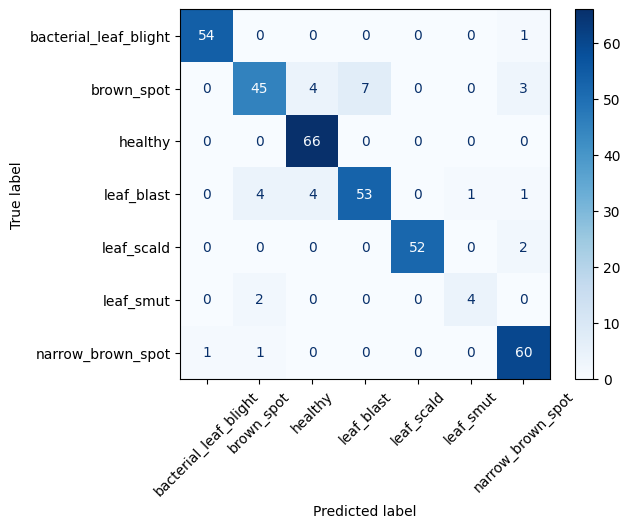

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(8,8))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

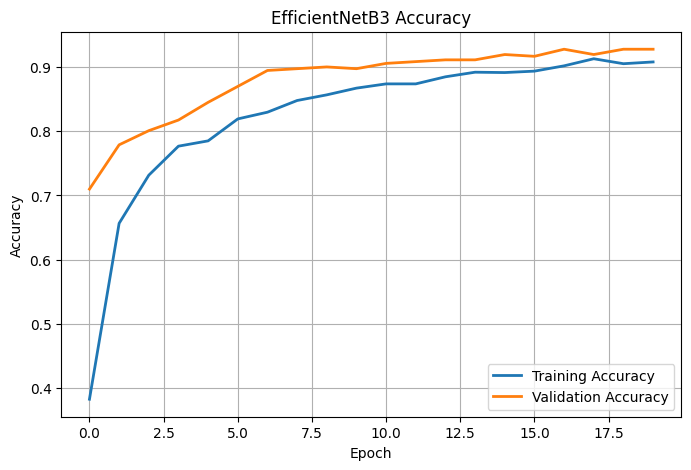

In [15]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)

plt.title('EfficientNetB3 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [16]:
efficientnet_model.save("efficientnetb3_final.keras")

print("EfficientNetB3 model saved successfully!")

EfficientNetB3 model saved successfully!
